In [1]:
#pip install matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Datasets/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [6]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

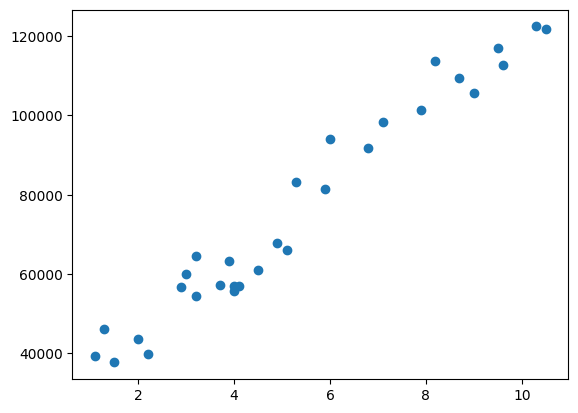

In [7]:
plt.scatter(df["YearsExperience"],df["Salary"])
plt.show()

In [8]:
df.corr()     #all columns are in numeric format

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [9]:
# X = df["YearsExperience"]
# X.head()

In [10]:
# y = df["Salary"]
# y.head()

In [11]:
X = df.iloc[ : , :-1]
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [12]:
y = df.iloc[ : , -1]
y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

In [13]:
X.shape

(30, 1)

In [14]:
y.shape

(30,)

In [15]:
# Split the data into training and testing
from sklearn.model_selection import train_test_split

In [16]:
#pip install scikit-learn

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [26]:
X_train.shape

(24, 1)

In [27]:
y_train.shape

(24,)

In [28]:
X_test.shape

(6, 1)

In [29]:
y_test.shape

(6,)

#### Training Simple Linear Regression Model on Training dataset

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
regressor = LinearRegression()

In [32]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# What is slope (coefficient) and constant(intercept)
print('Slope : ', regressor.coef_)
print('Constant : ', regressor.intercept_)

Slope :  [9312.57512673]
Constant :  26780.09915062818


In [34]:
# Equation of Line
y = 26780.09915062818 + 9312.57512673 * 2
y

45405.24940408818

In [35]:
y_train_predict = regressor.predict(X_train)

### Plot

[]

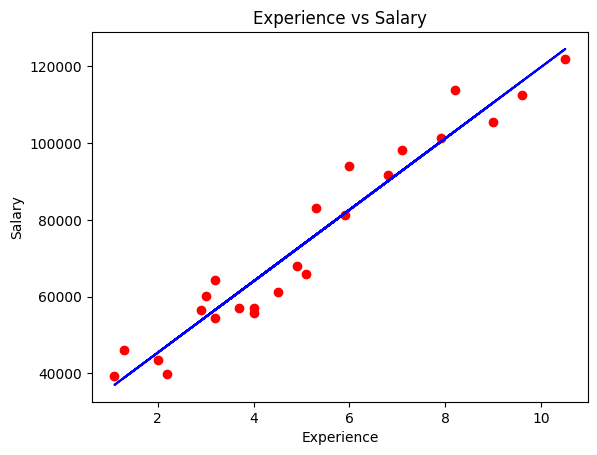

In [36]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, y_train_predict, color='blue')
plt.title('Experience vs Salary')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.plot()

In [37]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_train, y_train_predict)

6012.459573099956

In [38]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_train, y_train_predict)

36149670.11816131

In [39]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_train, y_train_predict)

5221.078554315732

In [40]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_train, y_train_predict)

0.07873234509387576